In [1]:
import numpy as np 
import pandas as pd
import optuna 
import os
import warnings 
import joblib

from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold

from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.base import clone

# simple models 
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, LinearSVC
# more complicated models 
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, ExtraTreesClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

RANDOM_STATE = 42
CSV_PATH = 'MODELING_CSV'
PIPELINE_JOBLIB = 'PIPELINE_PATH'
os.makedirs(CSV_PATH, exist_ok=True)
os.makedirs(PIPELINE_JOBLIB, exist_ok=True)

warnings.filterwarnings('ignore')

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover", "Dress",
    "Coat",
    "Sandal", "Shirt",
    "Sneaker", "Bag",
    "Ankle boot"
]

lr_params = {
    'random_state': RANDOM_STATE, 
    'n_jobs': 4,
    'max_iter': 2000,
    'C': 0.9,
}

best_variance_threshold = 0.0001

best_hog_params = {
    'orientations': 12,
    'pixels_per_cell': (4,4), 
    'cells_per_block': (2,2), 
}

# Load Data

In [2]:
train = pd.read_csv ('CSV_FILES/train.csv')
valid = pd.read_csv ('CSV_FILES/valid.csv')
data = pd.read_csv('fashion-mnist_train.csv')
test = pd.read_csv('fashion-mnist_test.csv')
train_small = pd.read_csv('CSV_FILES/train_small.csv')
valid_small = pd.read_csv('CSV_FILES/valid_small.csv')

x_train, y_train = train.drop ('label', axis = 1).copy(), train['label'].copy()
x_valid, y_valid = valid.drop ('label', axis = 1).copy(), valid['label'].copy()
x_data, y_data = data.drop ('label', axis = 1).copy(), data['label'].copy()
x_test, y_test = test.drop ('label', axis = 1).copy(), test['label'].copy()
x_train_small, y_train_small = train_small.drop ('label', axis = 1).copy(), train_small['label'].copy()
x_valid_small, y_valid_small = valid_small.drop ('label', axis = 1).copy(), valid_small['label'].copy()

In [3]:
x_train_processed_path = os.path.join (CSV_PATH, 'x_train_preprocessed.csv')
y_train_processed_path = os.path.join (CSV_PATH, 'y_train_preprocessed.csv')
x_valid_processed_path = os.path.join (CSV_PATH, 'x_valid_preprocessed.csv')
y_valid_processed_path = os.path.join (CSV_PATH, 'y_valid_preprocessed.csv')

x_train_processed_path_small = os.path.join (CSV_PATH, 'x_train_preprocessed_small.csv')
y_train_processed_path_small = os.path.join (CSV_PATH, 'y_train_preprocessed_small.csv')
x_valid_processed_path_small = os.path.join (CSV_PATH, 'x_valid_preprocessed_small.csv')
y_valid_processed_path_small = os.path.join (CSV_PATH, 'y_valid_preprocessed_small.csv')

def normalize (x): 
    x = x.copy()
    return x / 255.0

def extract_hog_features(x):
    x = x.copy()
    images = np.asarray(x).reshape(-1, 28, 28)
    features = [
        hog(image, **best_hog_params) for image in images
    ]
    return np.asarray(features, dtype=np.float32)

normalize_transformer = FunctionTransformer(normalize)
hog_transformer = FunctionTransformer(extract_hog_features)
data_pipeline = Pipeline ([
    ('normalize', normalize_transformer), 
    ('hog', hog_transformer), 
])

In [4]:
if not (
    os.path.exists(x_train_processed_path) and 
    os.path.exists(y_train_processed_path) and 
    os.path.exists(x_valid_processed_path) and
    os.path.exists(y_valid_processed_path) and
    os.path.exists(x_train_processed_path_small) and 
    os.path.exists(y_train_processed_path_small) and 
    os.path.exists(x_valid_processed_path_small) and
    os.path.exists(y_valid_processed_path_small)    
): 

    x_train_norm_hog = data_pipeline.fit_transform (x_train)
    x_valid_norm_hog = data_pipeline.transform (x_valid)
    x_train_norm_hog_small = data_pipeline.fit_transform (x_train_small)
    x_valid_norm_hog_small = data_pipeline.transform (x_valid_small)

    pd.DataFrame(x_train_norm_hog).to_csv(x_train_processed_path)
    pd.DataFrame(x_valid_norm_hog).to_csv(x_valid_processed_path)
    pd.DataFrame(x_train_norm_hog_small).to_csv(x_train_processed_path_small)
    pd.DataFrame(x_valid_norm_hog_small).to_csv(x_valid_processed_path_small)    
else: 
    x_train_norm_hog = pd.read_csv (x_train_processed_path)
    x_valid_norm_hog = pd.read_csv (x_valid_processed_path)
    x_train_norm_hog_small = pd.read_csv (x_train_processed_path_small)
    x_valid_norm_hog_small = pd.read_csv (x_valid_processed_path_small)

# Prepare Model

In [5]:
def prepare_pipeline (model, model_params):
    pipe = Pipeline([
        ('variance', VarianceThreshold(best_variance_threshold)),
        ('model', model(**model_params))
    ])

    return pipe

# Setup Model Pipelines 

In [6]:
lr_pipeline = prepare_pipeline(
    LogisticRegression,
    {
        "C": 0.9,
        "max_iter": 2000,
        "random_state": RANDOM_STATE,
        "n_jobs": 4,
    }
)

linear_svm_pipeline = prepare_pipeline(
    LinearSVC,
    {
        "C": 1.0,
        "max_iter": 5000,
        "random_state": RANDOM_STATE,
    }
)

rbf_svm_pipeline = prepare_pipeline(
    SVC,
    {
        "C": 10,
        "kernel": "rbf",
        "gamma": "scale",
        "random_state": RANDOM_STATE,
    }
)

knn_pipeline = prepare_pipeline(
    KNeighborsClassifier,
    {
        "n_neighbors": 5,
        "weights": "distance",
        "n_jobs": 4,
    }
)

rf_pipeline = prepare_pipeline(
    RandomForestClassifier,
    {
        "n_estimators": 750,
        "max_depth": None,
        "min_samples_split": 6,
        "min_samples_leaf": 3,
        "random_state": RANDOM_STATE,
        "n_jobs": 4,
    }
)

extra_trees_pipeline = prepare_pipeline(
    ExtraTreesClassifier,
    {
        "n_estimators": 750,
        "max_depth": None,
        "min_samples_split": 6,
        "min_samples_leaf": 3,
        "random_state": RANDOM_STATE,
        "n_jobs": 4,
    }
)

gradient_boosting_pipeline = prepare_pipeline(
    HistGradientBoostingClassifier,
    {
        "learning_rate": 0.1,
        "max_iter": 500,
        "max_leaf_nodes": 31,
        "random_state": RANDOM_STATE,
    }
)

mlp_pipeline = prepare_pipeline(
    MLPClassifier,
    {
        "hidden_layer_sizes": (256, 128),
        "activation": "relu",
        "alpha": 1e-4,
        "learning_rate_init": 1e-3,
        "max_iter": 200,
        "random_state": RANDOM_STATE,
    }
)

In [7]:
pipelines = [
    lr_pipeline,
    linear_svm_pipeline,
    rbf_svm_pipeline,
    knn_pipeline,
    rf_pipeline,
    extra_trees_pipeline,
    gradient_boosting_pipeline,
    mlp_pipeline,
]

pipe_results = []
pipe_results_path = os.path.join (CSV_PATH, 'PIPE_Results.csv')
if not os.path.exists(pipe_results_path):
    for pipe in pipelines: 
        name = f"{type(pipe.named_steps['model']).__name__}.joblib"
        pipe_path = os.path.join(PIPELINE_JOBLIB, name) 
        if not os.path.exists (pipe_path): 
            pipe.fit (x_train_norm_hog_small, y_train_small)
            joblib.dump (pipe, pipe_path)
        else: 
            pipe = joblib.load (pipe_path) 

        pred = pipe.predict (x_valid_norm_hog_small)
        f1 = f1_score(y_valid_small, pred, average='macro')
        acc = accuracy_score(y_valid_small, pred) 
        
        print (name, ' ', f1, ' ', acc)
        pipe_results.append ([name, f1, acc]) 

    pipe_results_df = pd.DataFrame(pipe_results, columns = ['name', 'f1', 'acc'])
    pipe_results_df.to_csv(pipe_results_path, index = False)
else: 
    pipe_results_df = pd.read_csv(pipe_results_path) 

display(pipe_results_df.sort_values('acc', ascending=False))

,name,f1,acc
6,HistGradientBoostingClassifier.joblib,0.876400,0.8780
2,SVC.joblib,0.874518,0.8755
0,LogisticRegression.joblib,0.863031,0.8640
7,MLPClassifier.joblib,0.861064,0.8620
1,LinearSVC.joblib,0.842699,0.8440
3,KNeighborsClassifier.joblib,0.840289,0.8420
4,RandomForestClassifier.joblib,0.836839,0.8420
5,ExtraTreesClassifier.joblib,0.836814,0.8415


Histogram Gradient Boosting & Supported Vector Machines have the best performance 

# Hyperparameter Tuning

In [8]:
svc_tuned_path = os.path.join (PIPELINE_JOBLIB, 'svc_best_params.joblib')
if not os.path.exists(svc_tuned_path): 
    def objective_svc(trial):
        C = trial.suggest_float("C", 1e-2, 100, log=True)
        gamma = trial.suggest_float("gamma", 1e-4, 1, log=True)

        pipe = prepare_pipeline(
            SVC,
            {
                "C": C,
                "kernel": "rbf",
                "gamma": gamma,
                "random_state": RANDOM_STATE,
            }
        )

        pipe.fit(x_train_norm_hog_small, y_train_small)
        pred = pipe.predict(x_valid_norm_hog_small)

        return f1_score(y_valid_small, pred, average="macro")

    svc_study = optuna.create_study(direction="maximize")
    svc_study.optimize(objective_svc, n_trials=30)
    svc_best_params = svc_study.best_params
    joblib.dump (svc_best_params, svc_tuned_path)
else: 
    svc_best_params = joblib.load(svc_tuned_path) 

In [9]:
hgb_params_path = os.path.join (PIPELINE_JOBLIB, 'hgb_params.joblib')
if not os.path.exists(hgb_params_path): 
    def objective_hgb(trial):
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        max_iter = trial.suggest_int("max_iter", 100, 400)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 15, 63)
        l2_regularization = trial.suggest_float("l2_regularization", 1e-6, 1.0, log=True)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 10, 50)

        pipe = prepare_pipeline(
            HistGradientBoostingClassifier,
            {
                "learning_rate": learning_rate,
                "max_iter": max_iter,
                "max_leaf_nodes": max_leaf_nodes,
                "l2_regularization": l2_regularization,
                "min_samples_leaf": min_samples_leaf,
                "random_state": RANDOM_STATE,
            }
        )

        pipe.fit(x_train_norm_hog_small, y_train_small)
        pred = pipe.predict(x_valid_norm_hog_small)

        return f1_score(y_valid_small, pred, average="macro")

    hgb_study = optuna.create_study(direction="maximize")
    hgb_study.optimize(objective_hgb, n_trials=30)
    hgb_best_params = hgb_study.best_params
    joblib.dump (hgb_best_params, hgb_params_path)
else: 
    hgb_best_params = joblib.load (hgb_params_path)

In [ ]:
svc_final_model_path = os.path.join (PIPELINE_JOBLIB, 'SVC_Final_Model.joblib')
svc_result_path = os.path.join (MODELING_CSV, 'tuned_svc_results')
svc_model = prepare_pipeline(SVC, svc_best_params)
if not os.path.exists(svc_final_model_path): 
    svc_model.fit (x_train_norm_hog, y_train)
    joblib.dump (svc_model, svc_final_model_path)
else: 
    svc_model = joblib.load (svc_final_model_path)

if not os.path.exists (svc_result_path):
    svc_pred = svc_model.predict (x_valid_norm_hog)
    svc_f1 = f1_score(svc_pred, y_valid, average='macro')
    svc_acc = accuracy_score(svc_pred, y_valid)
    svc_results_df = pd.DataFrame([['SVC_Tuned_Final', svc_f1, svc_acc]])
    svc_results_df.to_csv (svc_result_path)
else: 
    svc_results_df = pd.read_csv (svc_result_path)

In [ ]:
hgb_final_model_path = os.path.join (PIPELINE_JOBLIB, 'hgb_Final_Model.joblib')
hgb_result_path = os.path.join (MODELING_CSV, 'tuned_hgb_results')
hgb_model = prepare_pipeline(HistGradientBoostingClassifier, hgb_best_params)
if not os.path.exists(hgb_final_model_path): 
    hgb_model.fit (x_train_norm_hog, y_train)
    joblib.dump (hgb_model, hgb_final_model_path)
else: 
    hgb_model = joblib.load (hgb_final_model_path)

if not os.path.exists (hgb_result_path):
    hgb_pred = hgb_model.predict (x_valid_norm_hog)
    hgb_f1 = f1_score(hgb_pred, y_valid, average='macro')
    hgb_acc = accuracy_score(hgb_pred, y_valid)
    hgb_results_df = pd.DataFrame([['hgb_Tuned_Final', hgb_f1, hgb_acc]])
    hgb_results_df.to_csv (hgb_result_path)
else: 
    hgb_results_df = pd.read_csv (hgb_result_path)

# Performance Comparison

In [ ]:
final_performance_df = pd.concat ([svc_results_df, hgb_results_df], axis = 0)
final_performance_df

,0,1,2
0,SVC_Tuned_Final,0.911868,0.9122
0,hgb_Tuned_Final,0.890962,0.8912


SVC model outperforms HGB on both metric

In [ ]:
print ('Accuracy: ', svc_acc)
print (classification_report(svc_pred, y_valid))

Accuracy:  0.9122
              precision    recall  f1-score   support

           0       0.89      0.86      0.87      1031
           1       0.98      0.99      0.99       992
           2       0.87      0.87      0.87      1001
           3       0.92      0.90      0.91      1019
           4       0.87      0.85      0.86      1023
           5       0.97      0.97      0.97       998
           6       0.73      0.77      0.75       937
           7       0.96      0.94      0.95      1018
           8       0.98      0.98      0.98      1000
           9       0.95      0.97      0.96       981

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



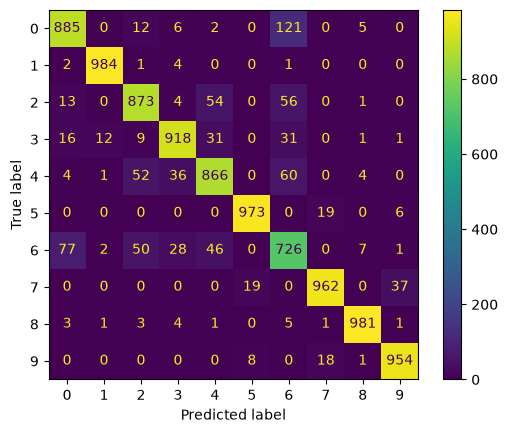

In [ ]:
ConfusionMatrixDisplay.from_predictions(svc_pred, y_valid)